<a href="https://colab.research.google.com/github/ektapatel-1612/credit-risk/blob/main/Credit_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Required Libraries

In [ ]:
!pip install shap xgboost -q

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import shap

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [ ]:
df = pd.read_csv('/content/Credit_Card.csv', sep=';')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


# Basic Information

In [ ]:
print("Shape:", df.shape)

df.info()

df.describe()

# Convert object columns to numeric

df['risk_leak'] = pd.to_numeric(
    df['risk_leak'],
    errors='coerce'
)

df['LIMIT_BAL_LOG'] = pd.to_numeric(
    df['LIMIT_BAL_LOG'],
    errors='coerce'
)

Shape: (34788, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34788 entries, 0 to 34787
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          34788 non-null  int64  
 1   LIMIT_BAL                   33079 non-null  float64
 2   SEX                         33021 non-null  float64
 3   EDUCATION                   33054 non-null  float64
 4   MARRIAGE                    33055 non-null  float64
 5   AGE                         33033 non-null  float64
 6   PAY_0                       34788 non-null  int64  
 7   PAY_2                       34788 non-null  int64  
 8   PAY_3                       34788 non-null  int64  
 9   PAY_4                       34788 non-null  int64  
 10  PAY_5                       34788 non-null  int64  
 11  PAY_6                       34788 non-null  int64  
 12  BILL_AMT1                   34788 non-null  float64
 13  BILL_AMT2   

# TASK 1 – EDA

Target Variable Distribution

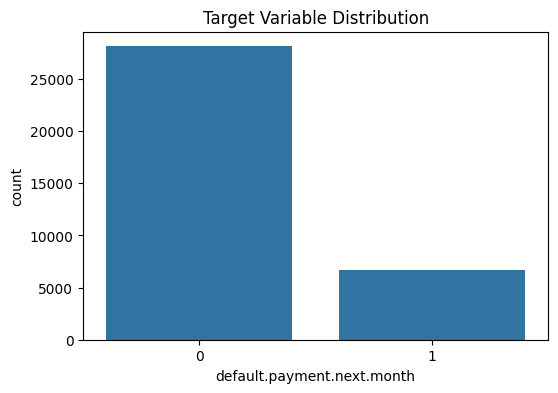

default.payment.next.month
0    28132
1     6656
Name: count, dtype: int64
default.payment.next.month
0    80.866966
1    19.133034
Name: proportion, dtype: float64


In [ ]:
target = "default.payment.next.month"

plt.figure(figsize=(6,4))

sns.countplot(
    x=target,
    data=df
)

plt.title("Target Variable Distribution")
plt.show()

print(df[target].value_counts())

print(
    df[target].value_counts(normalize=True)*100
)

Descriptive Statistics Required by Brief

In [ ]:
cols = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT_SUM',
    'LIMIT_BAL_LOG',
    'risk_leak'
]

df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,33079.0,184668.994831,235931.930924,10000.000000,60000.000000,140000.000000,240000.000000,5.600000e+06
AGE,33033.0,35.518300,9.236783,21.000000,28.000000,34.000000,41.000000,7.900000e+01
BILL_AMT_SUM,34788.0,294815.170892,571807.252079,-336259.000000,29738.250000,129037.000000,350209.500000,2.129266e+07
LIMIT_BAL_LOG,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
risk_leak,31401.0,0.096656,0.298594,-0.385208,-0.059318,0.015007,0.099241,9.999755e-01


Histograms

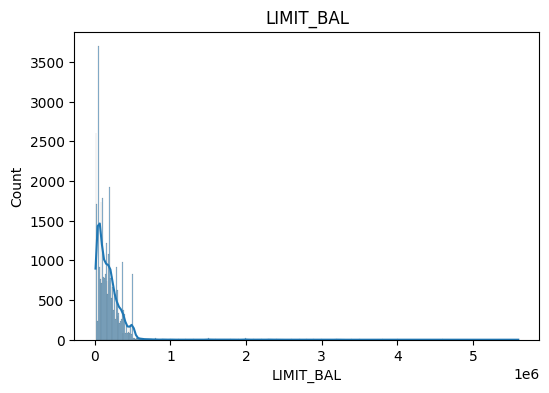

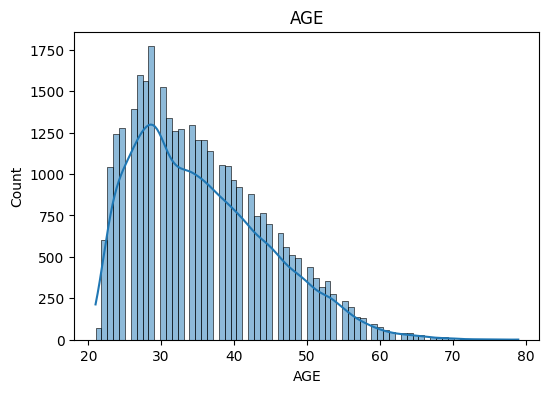

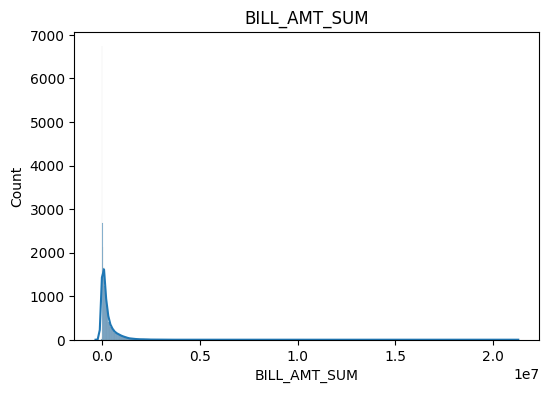

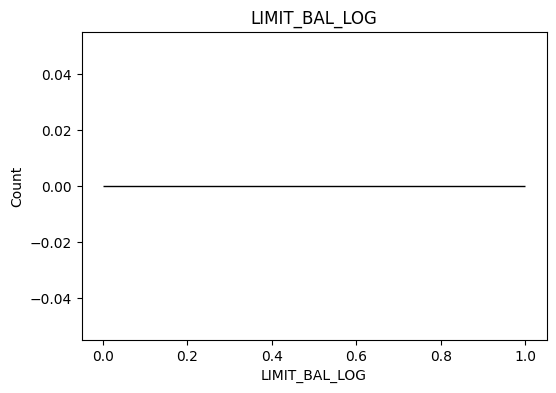

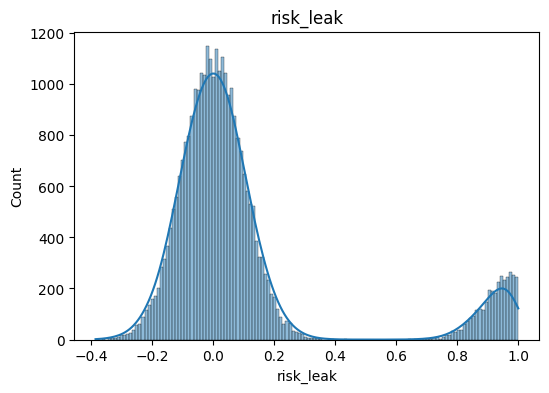

In [ ]:
for col in cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)
    plt.show()

Boxplots

LIMIT_BAL: 33079 values


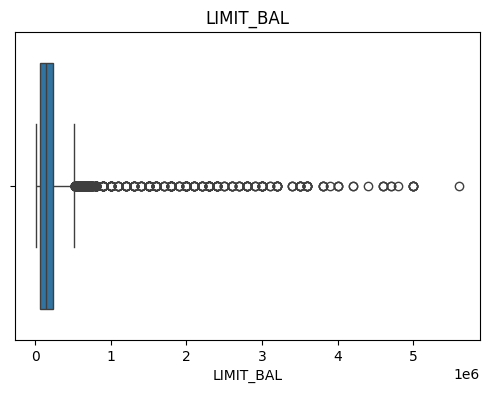

AGE: 33033 values


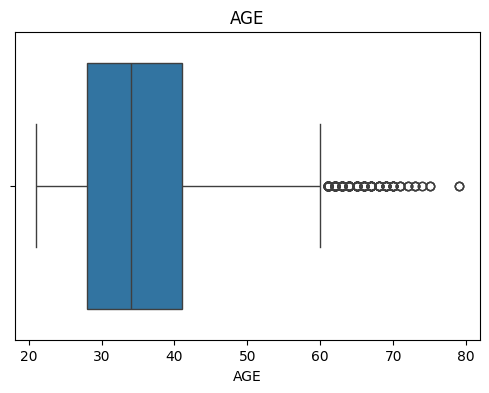

BILL_AMT_SUM: 34788 values


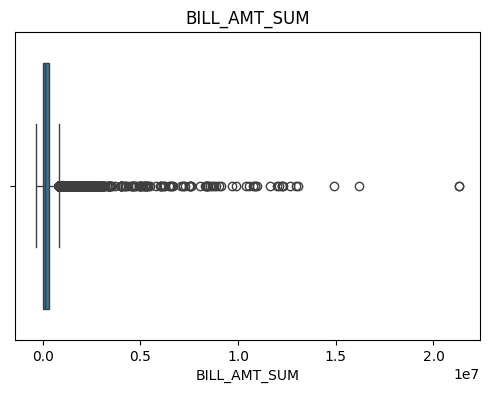

LIMIT_BAL_LOG: 0 values


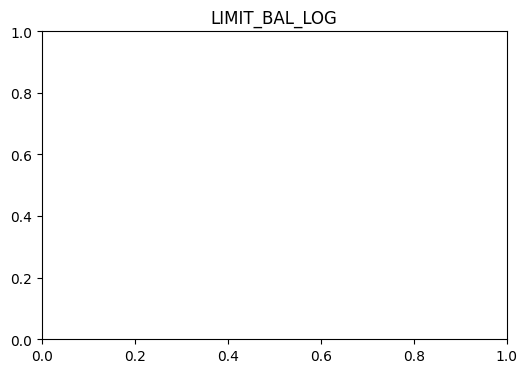

risk_leak: 31401 values


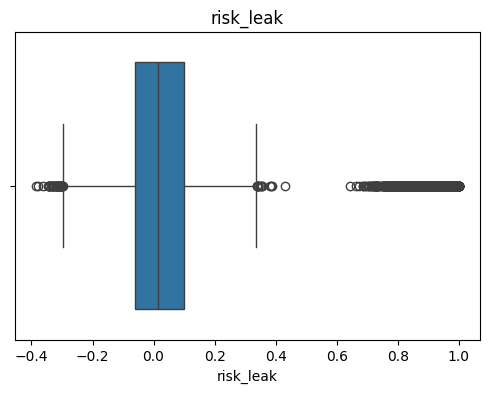

In [ ]:
for col in cols:

    temp = pd.to_numeric(df[col], errors='coerce')

    temp = temp.dropna()

    print(f"{col}: {len(temp)} values")

    plt.figure(figsize=(6,4))

    sns.boxplot(x=temp)

    plt.title(col)

    plt.show()

Categorical Features

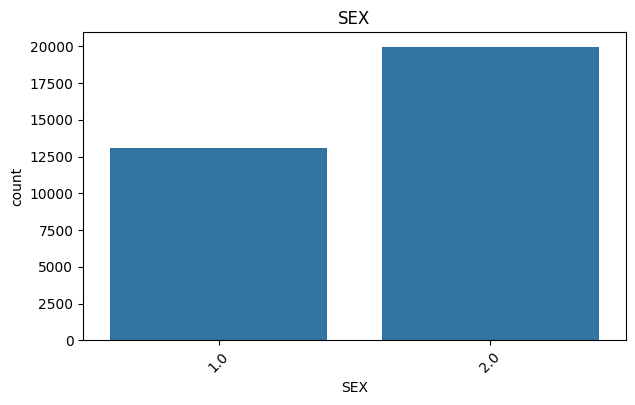

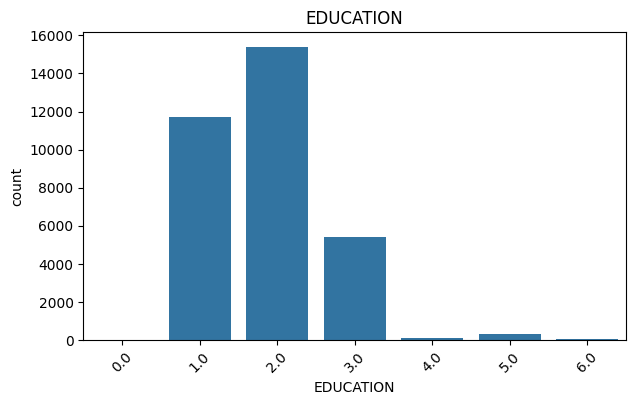

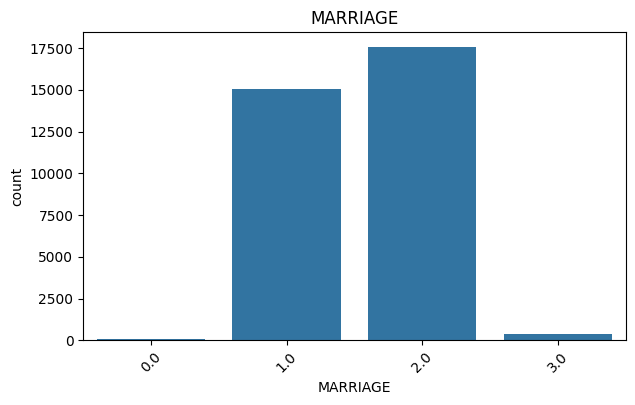

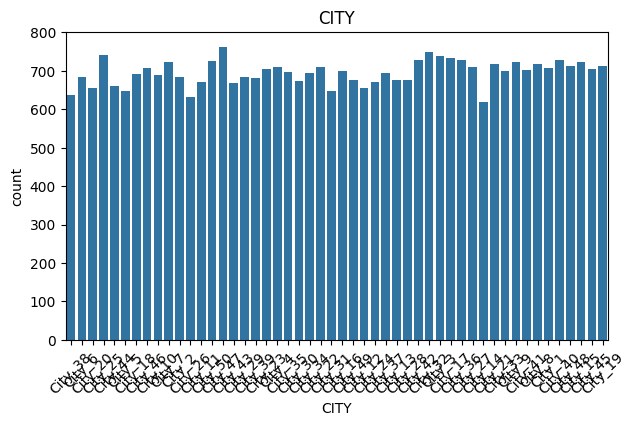

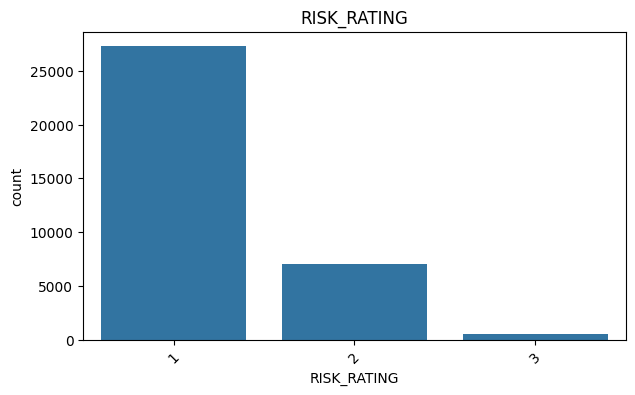

In [ ]:
categorical_cols = [
    'SEX',
    'EDUCATION',
    'MARRIAGE',
    'CITY',
    'RISK_RATING'
]

for col in categorical_cols:

    plt.figure(figsize=(7,4))

    sns.countplot(
        x=col,
        data=df
    )

    plt.title(col)

    plt.xticks(rotation=45)

    plt.show()

Correlation Analysis

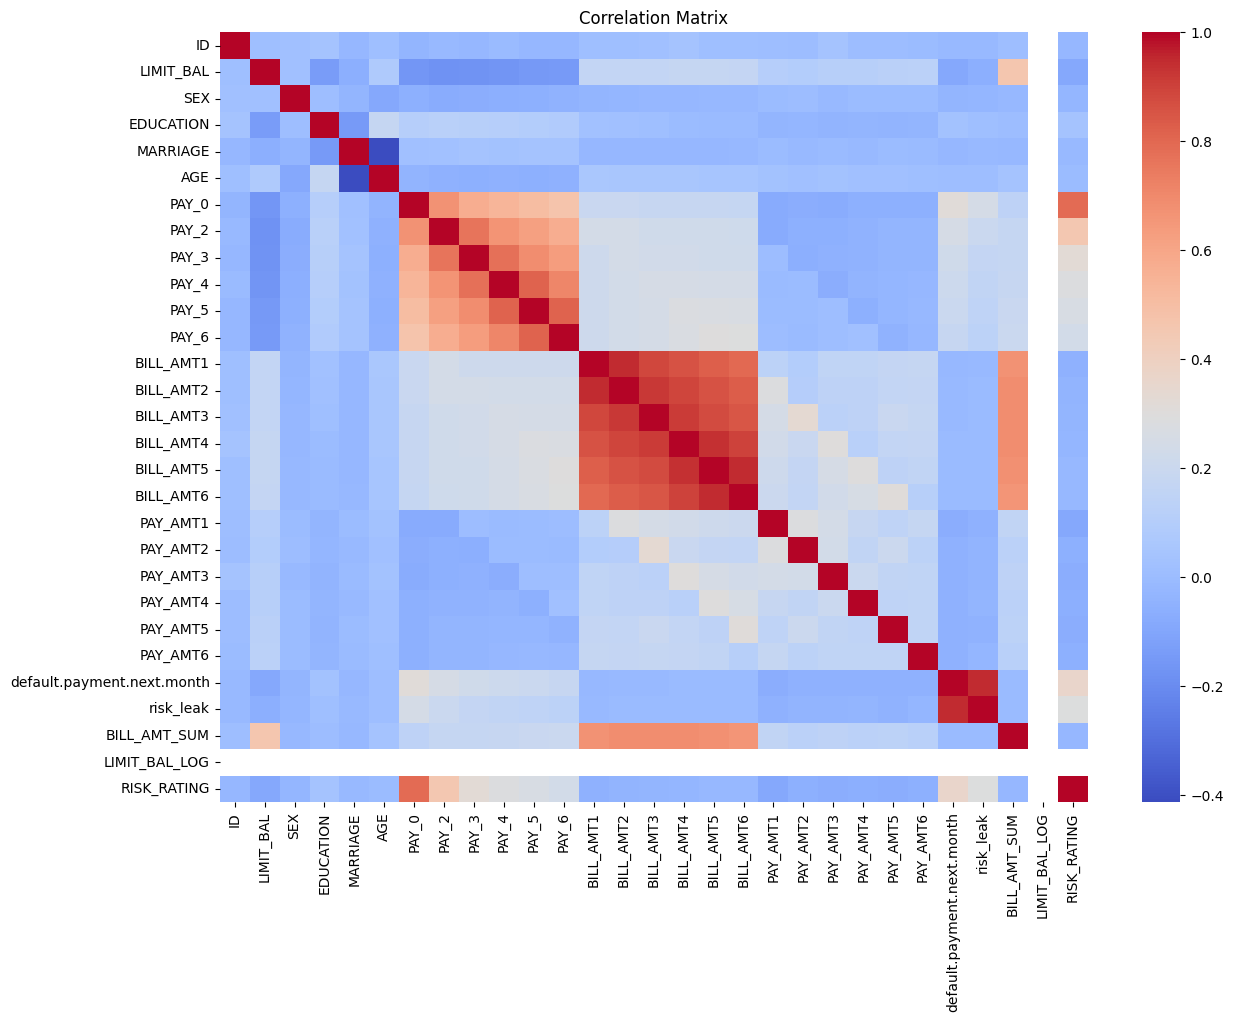

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

Correlation with Target

In [ ]:
corr_target = corr[target]

corr_target.sort_values(
    ascending=False
)

,default.payment.next.month
default.payment.next.month,1.000000
risk_leak,0.945344
RISK_RATING,0.362487
PAY_0,0.314230
PAY_2,0.253757
PAY_3,0.224862
PAY_4,0.207571
PAY_5,0.196277
PAY_6,0.179303
EDUCATION,0.028543


# TASK 2 – DATA PREPARATION

Missing Values

In [ ]:
missing = df.isnull().sum()

missing[missing > 0]

,0
LIMIT_BAL,1709
SEX,1767
EDUCATION,1734
MARRIAGE,1733
AGE,1755
PAY_AMT1,1725
PAY_AMT2,1744
risk_leak,3387
LIMIT_BAL_LOG,34788


In [ ]:
# Remove columns that are completely empty

df = df.dropna(axis=1, how='all')

# Recreate numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Impute CITY
df['CITY'] = df['CITY'].fillna(df['CITY'].mode()[0])

print("Remaining missing values:")
print(df.isnull().sum().sum())

Remaining missing values:
0


Imputation

In [ ]:
# Numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

num_imputer = SimpleImputer(strategy='median')

df[num_cols] = pd.DataFrame(
    num_imputer.fit_transform(df[num_cols]),
    columns=num_cols,
    index=df.index
)

# Categorical columns
cat_cols = ['CITY']

cat_imputer = SimpleImputer(strategy='most_frequent')

df[cat_cols] = pd.DataFrame(
    cat_imputer.fit_transform(df[cat_cols]),
    columns=cat_cols,
    index=df.index
)

Encoding

In [ ]:
df = pd.get_dummies(
    df,
    drop_first=True
)

Features and Target

In [ ]:
X = df.drop(
    "default.payment.next.month",
    axis=1
)

y = df[
    "default.payment.next.month"
]

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(27830, 76)
(6958, 76)


Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# TASK 3 – MODEL TRAINING

Models

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(),

    "SVM":
        SVC(probability=True),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier(),

    "KNN":
        KNeighborsClassifier()
}

Train Models

In [ ]:
results = []

trained_models = {}

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    trained_models[name] = model

    pred = model.predict(
        X_test_scaled
    )

    prob = model.predict_proba(
        X_test_scaled
    )[:,1]

    results.append([

        name,

        accuracy_score(
            y_test,
            pred
        ),

        precision_score(
            y_test,
            pred
        ),

        recall_score(
            y_test,
            pred
        ),

        f1_score(
            y_test,
            pred
        ),

        roc_auc_score(
            y_test,
            prob
        )
    ])

# TASK 4 – COMPARISON TABLE

In [ ]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]
)

results_df.sort_values(
    by='AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,AUC
3,Random Forest,0.962633,0.984615,0.817431,0.893268,0.998716
2,Decision Tree,0.998275,0.996986,0.993989,0.995485,0.996639
0,Logistic Regression,0.896522,0.878563,0.532682,0.663237,0.871303
1,SVM,0.907588,0.975138,0.530428,0.687105,0.852617
4,KNN,0.890486,0.859671,0.510894,0.640905,0.822721


Confusion Matrices

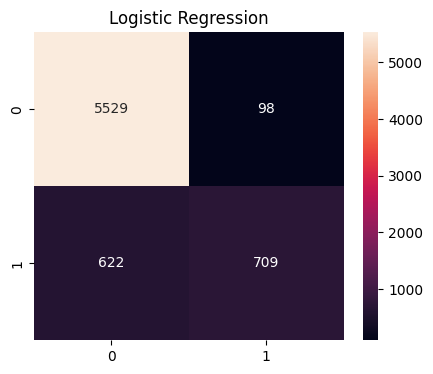

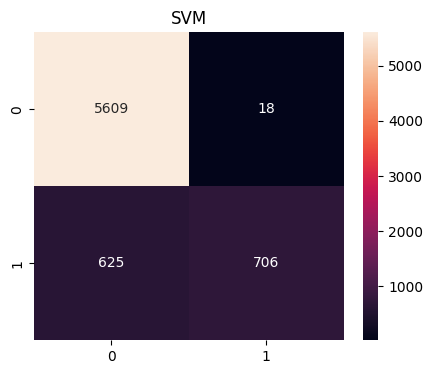

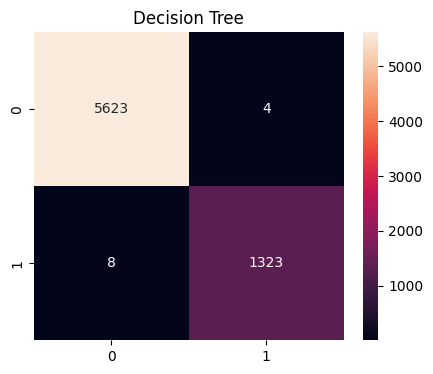

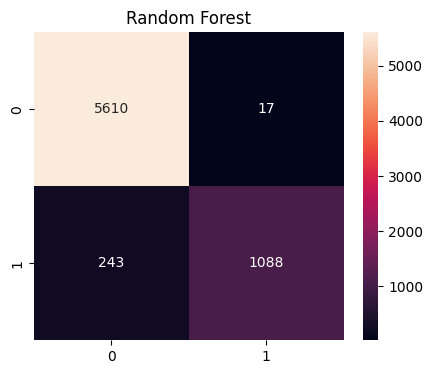

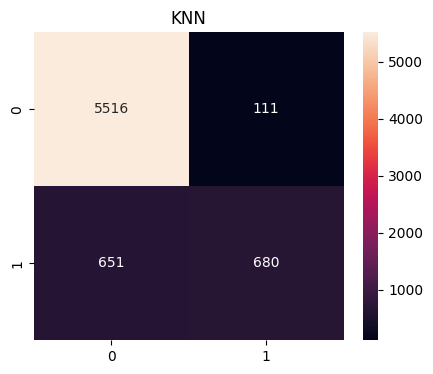

In [ ]:
for name, model in trained_models.items():

    pred = model.predict(
        X_test_scaled
    )

    cm = confusion_matrix(
        y_test,
        pred
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d'
    )

    plt.title(name)

    plt.show()

ROC Curves

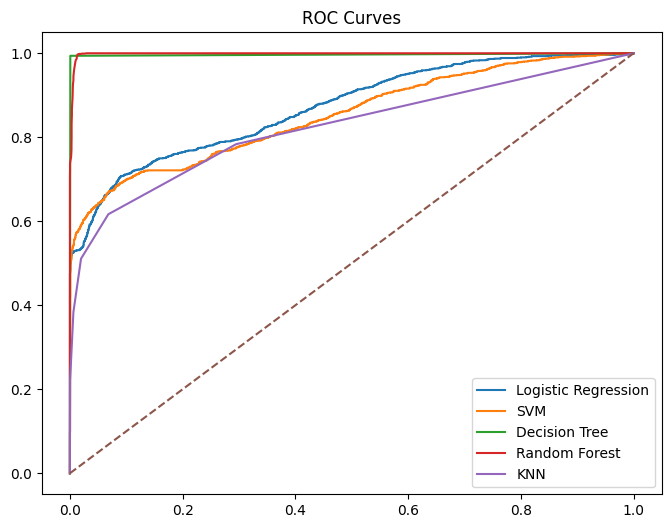

In [ ]:
plt.figure(figsize=(8,6))

for name, model in trained_models.items():

    prob = model.predict_proba(
        X_test_scaled
    )[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=name
    )

plt.plot([0,1],[0,1],'--')

plt.legend()

plt.title("ROC Curves")

plt.show()

Hyperparameter Tuning

In [ ]:
params = {

    'n_estimators':[100,200],

    'max_depth':[5,10,20],

    'min_samples_split':[2,5]
}

grid = GridSearchCV(

    RandomForestClassifier(),

    params,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1
)

grid.fit(
    X_train_scaled,
    y_train
)

print(grid.best_params_)

best_rf = grid.best_estimator_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


Tuned Model Evaluation

In [ ]:
pred = best_rf.predict(
    X_test_scaled
)

prob = best_rf.predict_proba(
    X_test_scaled
)[:,1]

print(

    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print(

    "AUC:",
    roc_auc_score(
        y_test,
        prob
    )
)

Accuracy: 0.9496981891348089
AUC: 0.9984769418990788


SHAP Analysis

In [ ]:
explainer = shap.TreeExplainer(
    best_rf
)

shap_values = explainer.shap_values(
    X_test
)

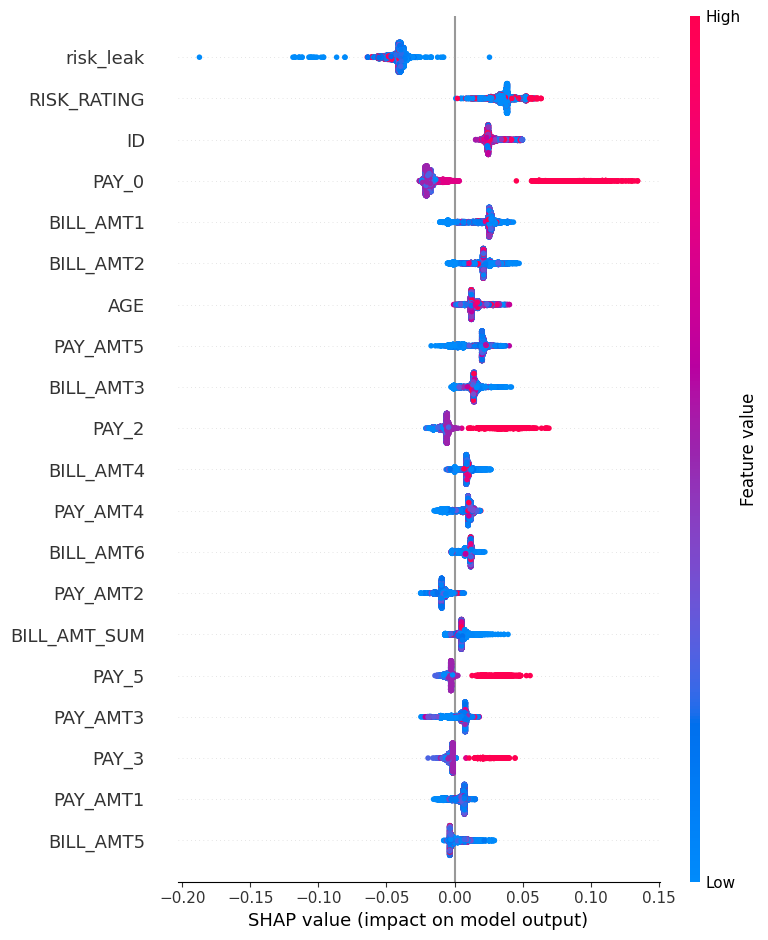

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

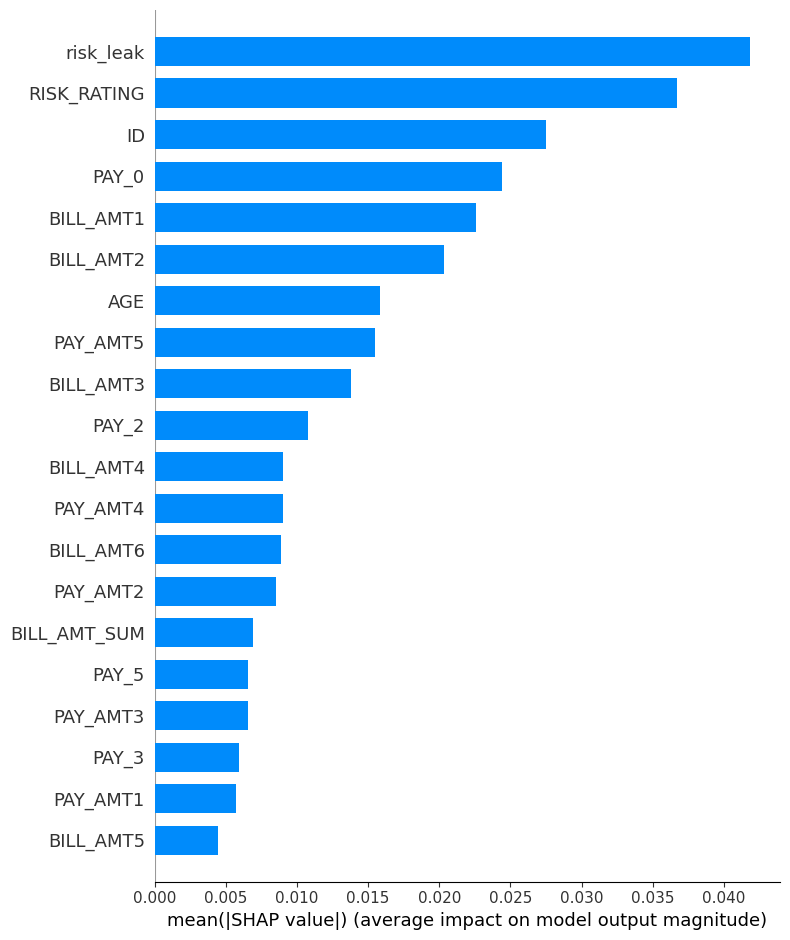

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar"
)

Feature Importance

In [ ]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
        best_rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

,Feature,Importance
24,risk_leak,0.515145
6,PAY_0,0.049448
26,RISK_RATING,0.035952
7,PAY_2,0.029183
0,ID,0.019568
12,BILL_AMT1,0.018548
25,BILL_AMT_SUM,0.018226
18,PAY_AMT1,0.017701
1,LIMIT_BAL,0.016851
8,PAY_3,0.016746
